# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

Os dados são criados a seguir:

In [16]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


In [17]:
t_statistic, p_valor = stats.ttest_ind(amostra_estrategia_B, amostra_estrategia_A)

# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




# Sua justificativa aqui
Em termos de fórmula, as hipóteses são: H0: μA = μB e H1: μB > μA, caracterizando um teste unilateral à direita, pois estamos interessados em verificar se a média da estratégia B é maior que a da estratégia A.


# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [18]:
#Seu código aqui
media_A = np.mean(amostra_estrategia_A)
variancia_A = np.var(amostra_estrategia_A)
desvio_A = np.std(amostra_estrategia_A)
media_B = np.mean(amostra_estrategia_B)  
variancia_B = np.var(amostra_estrategia_B)
desvio_B = np.std(amostra_estrategia_B)

print("Média A e Variancia A, respectivos", media_A, variancia_A )
print("Média B e Variancia B, respectivos", media_B, variancia_B)

Média A e Variancia A, respectivos 71.40559272313098 126.68018446943104
Média B e Variancia B, respectivos 74.74868110507046 108.26062024217782


A estratégia B apresentou uma média de notas superior à estratégia A, indicando melhor desempenho dos alunos. Além disso, a variância da estratégia B é menor, o que sugere que os resultados são mais consistentes e menos dispersos. Dessa forma, a estratégia B não apenas apresenta melhores notas em média, como também maior estabilidade nos resultados.

# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

Como o p-valor (0,13) é maior que o nível de significância (0,05), não rejeitamos a hipótese nula, ou seja, não há evidências suficientes para afirmar que a média da estratégia B é maior que a da estratégia A.

In [19]:
#Seu código aqui
print("Estatística de teste (t-statistic):", t_statistic)
print("p-valor:", p_valor)

Estatística de teste (t-statistic): 1.5267455833477102
p-valor: 0.13004538960951503


In [20]:
nivel_significancia = 0.05
if p_valor < nivel_significancia:
    print("Rejeitamos a hipótese nula: Rejeitamos a hipótese nula: há evidências de que a média das notas da estratégia B é maior que a da estratégia A.")
    print("Não temos evidências suficientes para rejeitar a hipótese nula: não há evidências suficientes para afirmar que a média das notas da estratégia B é maior que a da estratégia A.")


# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

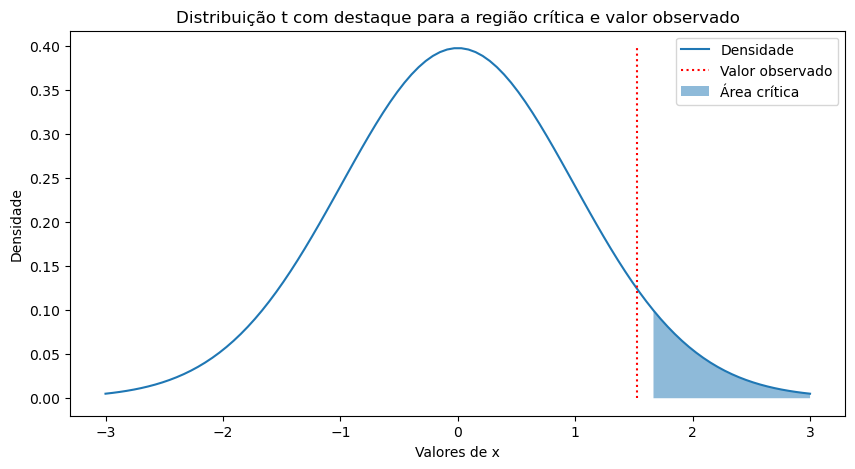

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

# Parâmetros da densidade sob H0
mu = 0 
variance = 1 
sigma = variance**.5  

# Valores de X e Y para plotar a densidade do nosso gráfico
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
y = stats.t.pdf(x, len(amostra_estrategia_B) + len(amostra_estrategia_A) - 2)

# Essas linhas de código estão calculando os limites da região crítica do teste t
low = stats.t.ppf(.95, len(amostra_estrategia_B) + len(amostra_estrategia_A) - 2)

high = np.inf

# Gráfico da densidade
ax.plot(x, y, label='Densidade')

# Marcação do valor observado da estatística do teste
ax.vlines(x=[t_statistic], ymin=0, ymax=y.max(), colors='r', linestyles='dotted', label='Valor observado')

# Preenchendo a área crítica
plt.fill_between(x, y, where=(low < x) & (x < high), alpha=.5, label='Área crítica')

#Plotagem padrão do gráfico
plt.legend()
plt.xlabel('Valores de x')
plt.ylabel('Densidade')
plt.title('Distribuição t com destaque para a região crítica e valor observado')
plt.show()

Como o valor observado da estatística do teste não está dentro da região crítica, não rejeitamos a hipótese nula. Isso indica que não há evidências suficientes para afirmar que a estratégia B apresenta média superior à estratégia A.